# Lab 4 — Random Forest & Decision Trees
**Machine Learning for the Natural Sciences**

Decision trees are the most intuitive classifier — they ask a series of
yes/no questions about your features. Random Forests combine many trees
into a single robust ensemble, and they hand you something no other
model we've seen gives for free: a ranked list of which features matter.

**What you'll learn:**
- How a single decision tree works — splits, entropy, information gain
- Random Forest: what an ensemble actually buys you (it's not always dramatic)
- Feature importance — the scientific payoff
- Model comparison — Random Forest vs. everything we've seen so far

---

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42

## 1. Prepare Data

In [2]:
df = sns.load_dataset("penguins").dropna()

feature_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = df[feature_cols]
y = df["species"]           # string labels — sklearn handles these directly

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Note: tree-based models do NOT need feature scaling!
print(f"Training: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Class counts in train: {y_train.value_counts().to_dict()}")

Training: 266 | Test: 67
Class counts in train: {'Adelie': 117, 'Gentoo': 95, 'Chinstrap': 54}


## 2. A Single Decision Tree
Let's start with one tree to see how it makes decisions.

> We pass `criterion="entropy"` so the math matches the Video 4.1 walkthrough
> exactly. The default (`"gini"`) gives nearly identical splits — switch back
> and see for yourself.

In [3]:
# Grow a tree with no depth limit so we can see its full structure
tree_deep = DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_STATE)
tree_deep.fit(X_train, y_train)

print(f"Training accuracy: {tree_deep.score(X_train, y_train):.3f}")
print(f"Test accuracy:     {tree_deep.score(X_test, y_test):.3f}")
print(f"Tree depth: {tree_deep.get_depth()}, Leaves: {tree_deep.get_n_leaves()}")

Training accuracy: 1.000
Test accuracy:     0.955
Tree depth: 5, Leaves: 11


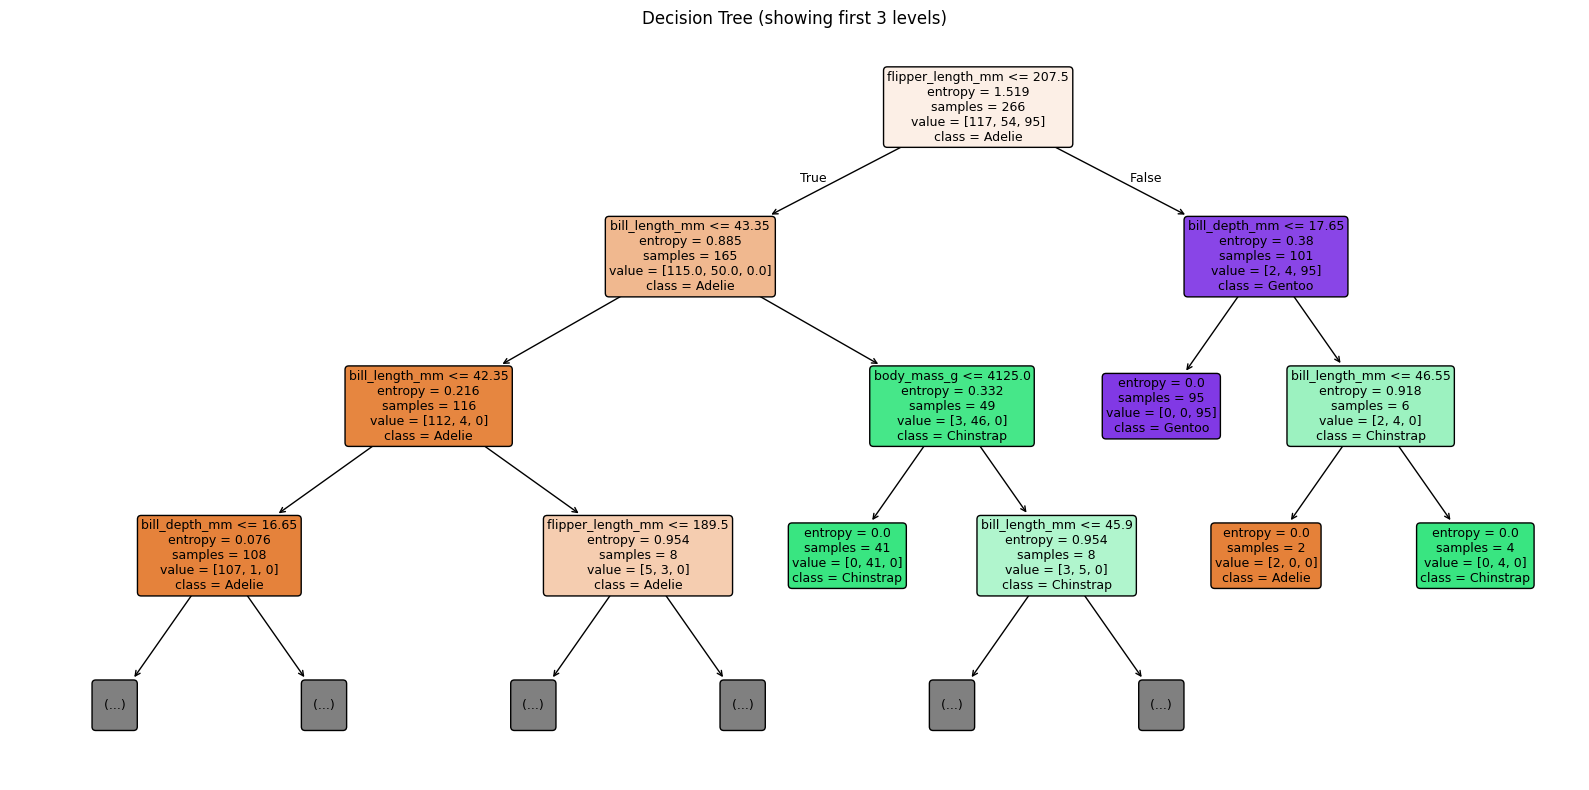

In [4]:
# Visualize the tree — this is the "series of questions" the model asks
plt.figure(figsize=(16, 8))
plot_tree(tree_deep, feature_names=feature_cols, class_names=tree_deep.classes_,
          filled=True, rounded=True, max_depth=3, fontsize=9)
plt.title("Decision Tree (showing first 3 levels)")
plt.tight_layout()
plt.show()

### 🔍 Your Turn
**TODO:** Look at the tree visualization. What is the very first question
the tree asks (the root split)? Why does that feature make sense as the
most important first split?

*Your answer:*

### How Depth Affects Accuracy
A tree with no depth limit grows until every leaf is pure. That's great
on this training set — but on harder data, that deep tree will memorize
noise. Let's sweep the `max_depth` and see how train and test accuracy
behave across a range. On Penguins the gap is small; on your Data Path
data it won't be.

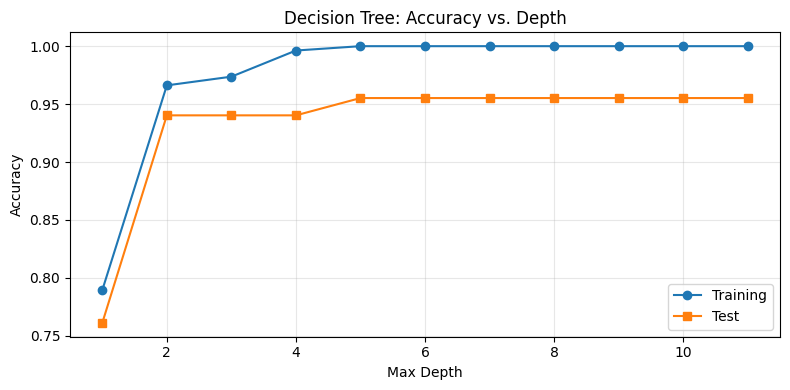

Best depth: 5 (test accuracy: 0.955)


In [5]:
# Sweep max_depth — train vs. test accuracy
depths = range(1, 12)
train_accs, test_accs = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, criterion="entropy",
                                  random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_accs.append(tree.score(X_train, y_train))
    test_accs.append(tree.score(X_test, y_test))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_accs, "o-", label="Training")
plt.plot(depths, test_accs, "s-", label="Test")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Accuracy vs. Depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths[int(np.argmax(test_accs))]
print(f"Best depth: {best_depth} (test accuracy: {max(test_accs):.3f})")

## 3. Random Forest
Instead of relying on one tree, we build **many** trees on random subsets
of the data and features, then take a majority vote. This is called
**bagging** (bootstrap aggregating).

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=rf.classes_))

Random Forest Accuracy: 0.970

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.96      0.98        24

    accuracy                           0.97        67
   macro avg       0.96      0.97      0.96        67
weighted avg       0.97      0.97      0.97        67



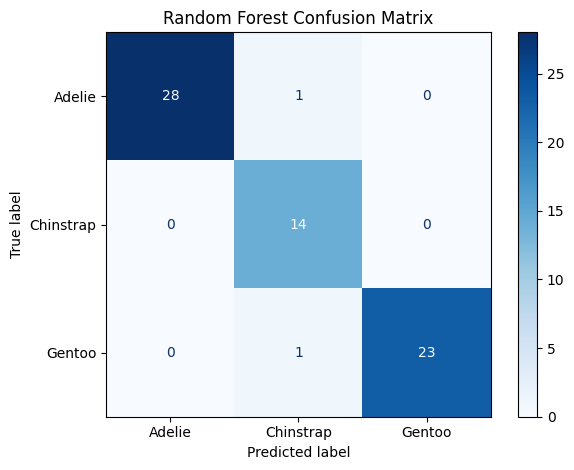

In [7]:
# Confusion matrix — sklearn infers class labels from the fitted model
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## 4. Feature Importance
One of the best things about Random Forests — they tell you which
features matter most. This is invaluable for natural science applications.

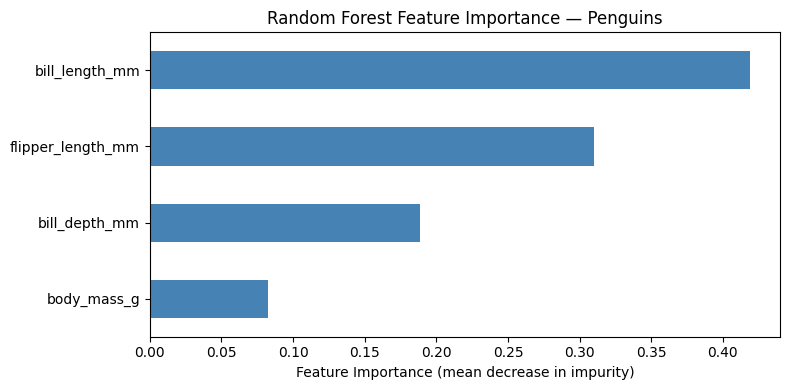


Feature Importance Ranking:
  bill_length_mm: 0.419
  flipper_length_mm: 0.310
  bill_depth_mm: 0.189
  body_mass_g: 0.083


In [8]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind="barh", color="steelblue")
plt.xlabel("Feature Importance (mean decrease in impurity)")
plt.title("Random Forest Feature Importance — Penguins")
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for feat, imp in importances.sort_values(ascending=False).items():
    print(f"  {feat}: {imp:.3f}")

### 🔍 Your Turn
**TODO:** Which feature is most important? Does this match what you saw
in the decision tree root split and in your Week 1 pairplot?

*Your answer:*

## 5. Comparison: All Models So Far

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Scale for models that need it (trees don't)
scaler = StandardScaler()

all_models = {
    "KNN (k=5)":     KNeighborsClassifier(n_neighbors=5),
    "Logistic Reg":  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Naive Bayes":   GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=best_depth, criterion="entropy",
                                            random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

print(f"{'Model':<20} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 42)
for name, model in all_models.items():
    use_scaled = name in ["KNN (k=5)", "Logistic Reg", "Naive Bayes"]
    data = scaler.fit_transform(X) if use_scaled else X
    scores = cross_val_score(model, data, y, cv=5)
    print(f"{name:<20} {scores.mean():>10.3f} {scores.std():>10.3f}")

Model                   CV Mean     CV Std
------------------------------------------
KNN (k=5)                 0.985      0.009
Logistic Reg              0.991      0.012
Naive Bayes               0.970      0.013
Decision Tree             0.964      0.023
Random Forest             0.979      0.015


### 🔍 Your Turn
**TODO:**
1. Does Random Forest beat the simpler models? By how much?

   *Your answer:*

2. Why don't tree-based models need feature scaling?
   (Hint: think about how a decision tree splits — does it care about
   the absolute scale of a feature?)

   *Your answer:*

3. What is the tradeoff between a single decision tree and a random
   forest? (Think about interpretability vs. accuracy.)

   *Your answer:*

---
## What to Submit
1. PDF with answers to all **🔍 Your Turn** sections
2. Feature importance bar chart and at least one confusion matrix
3. The all-models comparison table

## What's Next
**Data Adventure 2** — apply Random Forest to your Data Path dataset.
**Week 5** covers **Support Vector Machines** — a completely different
approach that finds the widest possible margin between classes.